In [50]:
# === 导入必要的库 ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. 处理政治稳定变量
从 WGI 数据集中提取 `Political Stability and Absence of Violence/Terrorism` 指标。

In [51]:
# === 处理政治稳定变量 ===
# 读取 WGI 数据
wgi_path = '../data/raw/wgidataset_excel/wgidataset.xlsx'
wgi_df = pd.read_excel(wgi_path)

# 筛选 Political Stability 指标
wgi_df = wgi_df[wgi_df['indicator'] == 'pv']

# 保留国家代码、年份和估计值
wgi_df = wgi_df[['code', 'year', 'estimate']].rename(
    columns={'code': 'iso3', 'year': 'year', 'estimate': 'political_stability'}
)

# 筛选研究时间段（2019-2022 年）
wgi_df = wgi_df[wgi_df['year'].between(2019, 2022)]

# 将 ".." 替换为 NaN，之前已经查看过了，这个数据集的缺失值用..代替的
wgi_df['political_stability'] = pd.to_numeric(wgi_df['political_stability'], errors='coerce')

# 检查缺失值
print("政治稳定变量缺失值统计：")
print(wgi_df.isnull().sum())

# # 删除缺失值
# wgi_df = wgi_df.dropna(subset=['political_stability'])

# # 检查缺失值
# print("去空值后政治稳定变量缺失值统计：")
# print(wgi_df.isnull().sum())

# 保存中间结果
output_path = '../data/processed/control_political_stability.csv'
wgi_df.to_csv(output_path, index=False)
print(f"政治稳定变量已保存到: {output_path}")

政治稳定变量缺失值统计：
iso3                   0
year                   0
political_stability    4
dtype: int64
政治稳定变量已保存到: ../data/processed/control_political_stability.csv


经检查：缺失的四个都是Netherlands Antilles (former)（2019-2022），暂时先没删除

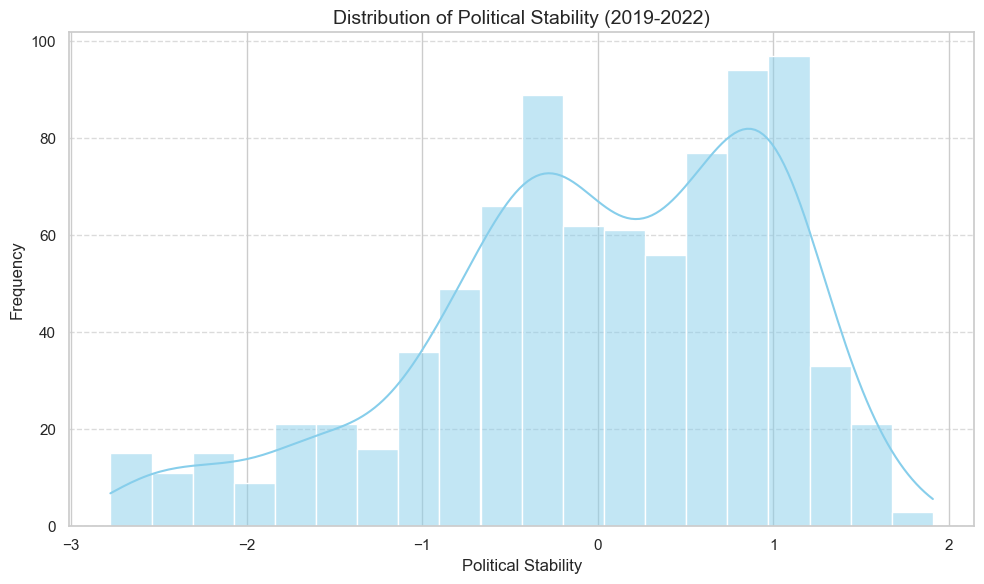

In [52]:
# 设置绘图样式
sns.set_theme(style="whitegrid")

# 绘制分布图
plt.figure(figsize=(10, 6))
sns.histplot(wgi_df['political_stability'].dropna(), bins=20, kde=True, color='skyblue')
plt.title("Distribution of Political Stability (2019-2022)", fontsize=14)
plt.xlabel("Political Stability", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. 处理人均 GDP
从 WDI 数据集中提取 `NY.GDP.PCAP.CD` 指标，取对数并滞后 1 年。

In [53]:
# === 处理人均 GDP ===
# 读取 WDI 数据
wdi_path = '../data/raw/WDI_CSV_2025_07_02/WDICSV.csv'
wdi_df = pd.read_csv(wdi_path)

# 筛选人均 GDP 指标
gdp_df = wdi_df[wdi_df['Indicator Code'] == 'NY.GDP.PCAP.CD']

In [54]:
# 转换为长表格式
gdp_df = gdp_df.melt(
    id_vars=['Country Code'],
    value_vars=[str(y) for y in range(2018, 2023)],  # 包含滞后年份
    var_name='year',
    value_name='gdp_pc'
)

# 取对数并滞后 1 年
gdp_df['gdp_pc'] = np.log(gdp_df['gdp_pc'])
gdp_df['year'] = gdp_df['year'].astype(int) + 1

# 重命名列
gdp_df = gdp_df.rename(columns={'Country Code': 'iso3'})

# 筛选研究时间段
gdp_df = gdp_df[gdp_df['year'].between(2019, 2022)]

In [55]:
# 检查缺失值
print("人均 GDP 缺失值统计：")
missing_summary = gdp_df.isnull().sum()
print(missing_summary)

# 分类统计缺失值的国家和年份
missing_gdp = gdp_df[gdp_df['gdp_pc'].isnull()]
missing_by_country = missing_gdp.groupby('iso3')['year'].apply(list).reset_index(name='missing_years')

# 打印缺失值的国家和年份
print("\n缺失人均 GDP 的国家和年份：")
print(missing_by_country)


人均 GDP 缺失值统计：
iso3       0
year       0
gdp_pc    31
dtype: int64

缺失人均 GDP 的国家和年份：
  iso3             missing_years
0  CUB                    [2022]
1  ERI  [2019, 2020, 2021, 2022]
2  GIB  [2019, 2020, 2021, 2022]
3  INX  [2019, 2020, 2021, 2022]
4  MAF              [2019, 2021]
5  PRK  [2019, 2020, 2021, 2022]
6  SSD  [2019, 2020, 2021, 2022]
7  VEN  [2019, 2020, 2021, 2022]
8  VGB  [2019, 2020, 2021, 2022]


### 3. 处理人口总数
从 WDI 数据集中提取 `SP.POP.TOTL` 指标，取对数。

In [56]:
# === 处理人口总数 ===
# 筛选人口总数指标
pop_df = wdi_df[wdi_df['Indicator Code'] == 'SP.POP.TOTL']

# 转换为长表格式
pop_df = pop_df.melt(
    id_vars=['Country Code'],
    value_vars=[str(y) for y in range(2019, 2023)],
    var_name='year',
    value_name='pop'
)

# 取对数
pop_df['pop'] = np.log(pop_df['pop'])

# 重命名列
pop_df = pop_df.rename(columns={'Country Code': 'iso3'})

### 4. 处理城市化率
从 WDI 数据集中提取 `SP.URB.TOTL.IN.ZS` 指标，保持原始比例。

In [57]:
# === 处理城市化率 ===
# 筛选城市化率指标
urban_df = wdi_df[wdi_df['Indicator Code'] == 'SP.URB.TOTL.IN.ZS']

# 转换为长表格式
urban_df = urban_df.melt(
    id_vars=['Country Code'],
    value_vars=[str(y) for y in range(2019, 2023)],
    var_name='year',
    value_name='urban'
)

# 重命名列
urban_df = urban_df.rename(columns={'Country Code': 'iso3'})

### 5. 处理失业率
从 WDI 数据集中提取 `SL.UEM.TOTL.ZS` 指标，滞后 1 年并插值。

In [58]:
# === 处理失业率 ===
# 筛选失业率指标
unemp_df = wdi_df[wdi_df['Indicator Code'] == 'SL.UEM.TOTL.ZS']

# 转换为长表格式
unemp_df = unemp_df.melt(
    id_vars=['Country Code'],
    value_vars=[str(y) for y in range(2018, 2023)],  # 包含滞后年份
    var_name='year',
    value_name='unemp'
)

# 滞后 1 年
unemp_df['year'] = unemp_df['year'].astype(int) + 1

# 重命名列
unemp_df = unemp_df.rename(columns={'Country Code': 'iso3'})

# 筛选研究时间段
unemp_df = unemp_df[unemp_df['year'].between(2019, 2022)]

### 6. 处理地理距离
从 CEPII 数据集中提取 `distwces` 指标，取对数。

In [59]:
# === 处理地理距离 ===
# 读取 CEPII 数据
cepii_path = '../data/raw/dist_cepii/dist_cepii.xls'
dist_df = pd.read_excel(cepii_path)

# 筛选需要的列
dist_df = dist_df[['iso_o', 'iso_d', 'distwces', 'distcap']]

In [60]:
# # 检查 distwces 列的数据类型
print("distwces 列的数据类型：", dist_df['distwces'].dtype)

# 将 distwces 列的缺失值用 distcap 填补
dist_df['distwces'] = dist_df['distwces'].replace('.', np.nan)
dist_df['distwces'] = pd.to_numeric(dist_df['distwces'], errors='coerce')
dist_df['distcap'] = pd.to_numeric(dist_df['distcap'], errors='coerce')

# 填补缺失值
dist_df['distwces'] = dist_df['distwces'].fillna(dist_df['distcap'])

# 检查填补后的缺失值情况
print("填补后 distwces 列的缺失值数量：\n", dist_df.isnull().sum())

distwces 列的数据类型： object
填补后 distwces 列的缺失值数量：
 iso_o       0
iso_d       0
distwces    0
distcap     0
dtype: int64


C:\Users\cmy\AppData\Local\Temp\ipykernel_11876\2292598012.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dist_df['distwces'] = dist_df['distwces'].replace('.', np.nan)


In [61]:
# 检查缺失值和非正值
print("缺失值数量：", dist_df['distwces'].isnull().sum())
print("非正值数量：", (pd.to_numeric(dist_df['distwces'], errors='coerce') <= 0).sum())

# 查看 distwces 列的统计信息
print("distwces 列的统计信息：")
print(dist_df.describe())


缺失值数量： 0
非正值数量： 0
distwces 列的统计信息：
           distwces       distcap
count  50176.000000  50176.000000
mean    8462.898831   8471.597042
std     4703.545522   4704.894938
min        0.008790      0.995137
25%     4746.304750   4768.617750
50%     8081.734500   8080.471000
75%    11976.977500  12004.520000
max    19888.660000  19951.160000


In [62]:
# 取对数
dist_df['distwces'] = np.log(dist_df['distwces'])

# 重命名列
dist_df = dist_df.rename(columns={'iso_o': 'origin_iso3', 'iso_d': 'destination_iso3', 'distwces': 'control_distwces'})

### 缺失值查看

In [63]:
# === 缺失值总结 ===

# 定义一个函数来统计缺失值的国家和年份
def summarize_missing_values(df, value_column, id_column='iso3', time_column='year'):
    missing = df[df[value_column].isnull()]
    missing_summary = missing.groupby(id_column)[time_column].apply(list).reset_index(name='missing_years')
    return missing_summary

# 统计各控制变量的缺失值
missing_summary = {}

# 政治稳定
missing_summary['political_stability'] = summarize_missing_values(wgi_df, 'political_stability')

# 人均 GDP
missing_summary['gdp_pc'] = summarize_missing_values(gdp_df, 'gdp_pc')

# 人口总数
missing_summary['pop'] = summarize_missing_values(pop_df, 'pop')

# 城市化率
missing_summary['urban'] = summarize_missing_values(urban_df, 'urban')

# 失业率
missing_summary['unemp'] = summarize_missing_values(unemp_df, 'unemp')


# 打印缺失值总结
for var, summary in missing_summary.items():
    print(f"\n缺失 {var} 的国家和年份：")
    print(summary)

# === 检查是否是相同的国家 ===
# 获取所有缺失值的国家集合
missing_countries = {var: set(summary['iso3']) for var, summary in missing_summary.items()}

# 找出所有变量都缺失的国家
common_missing_countries = set.intersection(*missing_countries.values())
print("\n所有变量都缺失的国家：", common_missing_countries)

# === 思考缺失值处理 ===
# 如果缺失值集中在少数国家，可以考虑删除这些国家的数据
# 如果缺失值分散，可以尝试插值或填充缺失值


缺失 political_stability 的国家和年份：
  iso3             missing_years
0  ANT  [2019, 2020, 2021, 2022]

缺失 gdp_pc 的国家和年份：
  iso3             missing_years
0  CUB                    [2022]
1  ERI  [2019, 2020, 2021, 2022]
2  GIB  [2019, 2020, 2021, 2022]
3  INX  [2019, 2020, 2021, 2022]
4  MAF              [2019, 2021]
5  PRK  [2019, 2020, 2021, 2022]
6  SSD  [2019, 2020, 2021, 2022]
7  VEN  [2019, 2020, 2021, 2022]
8  VGB  [2019, 2020, 2021, 2022]

缺失 pop 的国家和年份：
  iso3             missing_years
0  INX  [2019, 2020, 2021, 2022]

缺失 urban 的国家和年份：
  iso3             missing_years
0  INX  [2019, 2020, 2021, 2022]
1  MAF  [2019, 2020, 2021, 2022]
2  XKX  [2019, 2020, 2021, 2022]

缺失 unemp 的国家和年份：
   iso3             missing_years
0   ABW  [2019, 2020, 2021, 2022]
1   AND  [2019, 2020, 2021, 2022]
2   ASM  [2019, 2020, 2021, 2022]
3   ATG  [2019, 2020, 2021, 2022]
4   BMU  [2019, 2020, 2021, 2022]
5   CUW  [2019, 2020, 2021, 2022]
6   CYM  [2019, 2020, 2021, 2022]
7   DMA  [2019, 2020, 2021, 202

### 7. 控制变量输出

In [64]:
# === 输出 WDI 数据中的控制变量 ===
# 确保所有数据框的 year 列为 int 类型
gdp_df['year'] = gdp_df['year'].astype(int)
pop_df['year'] = pop_df['year'].astype(int)
urban_df['year'] = urban_df['year'].astype(int)
unemp_df['year'] = unemp_df['year'].astype(int)

# 合并 WDI 数据中的控制变量
wdi_control_vars = gdp_df.merge(pop_df, on=['iso3', 'year'], how='outer') \
                         .merge(urban_df, on=['iso3', 'year'], how='outer') \
                         .merge(unemp_df, on=['iso3', 'year'], how='outer') 

# 保存 WDI 控制变量到文件
wdi_output_path = '../data/processed/control_wdi_variables.csv'
wdi_control_vars.to_csv(wdi_output_path, index=False)
print(f"WDI 控制变量已保存到: {wdi_output_path}")

# === 输出地理距离数据 ===

# 只保留重命名后的列
dist_df = dist_df[['origin_iso3', 'destination_iso3', 'control_distwces']]

# 保存地理距离数据到文件
dist_output_path = '../data/processed/control_distwces.csv'
dist_df.to_csv(dist_output_path, index=False)
print(f"地理距离数据已保存到: {dist_output_path}")

WDI 控制变量已保存到: ../data/processed/control_wdi_variables.csv
地理距离数据已保存到: ../data/processed/control_distwces.csv
